# Fase 2b: Continuación del entrenamiento de la CNN From Scratch

## Contexto
La primera corrida de 30 épocas (notebook `01_cnn_from_scratch.ipynb`) alcanzó **39.20% de test accuracy**, a 0.8 puntos del umbral mínimo de 40%. Las curvas mostraron que la red seguía aprendiendo (val_loss descendiendo hasta la última época, mejor modelo guardado en la época 30). No hay overfitting — solo subentrenamiento.

## Estrategia de continuación

1. **Cargar** el state_dict de `models/cnn_scratch_best.pt` (el mejor modelo hasta época 30).
2. **Continuar** hasta **15 épocas adicionales** con el mismo setup:
   - Optimizador Adam, LR inicial 0.001, weight_decay 1e-4
   - Scheduler `ReduceLROnPlateau` reinicializado (mismo factor=0.5, patience=3)
3. **Early stopping manual:** si `val_loss` sube de forma sostenida 3 épocas seguidas, detener.
4. **Seguir guardando** el mejor modelo (menor val_loss) en el mismo `models/cnn_scratch_best.pt`, inicializando `best_val_loss` con el valor de la corrida previa (2.4436).
5. **Curva combinada:** 30 épocas originales + N épocas nuevas, con línea vertical marcando la reanudación.
6. **Evaluar en test** al terminar y reportar la nueva accuracy.

In [1]:
import sys
sys.path.append('..')
import re
import time
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import nbformat
from pathlib import Path
from tqdm import tqdm

from src.data import get_dataloaders
from src.model import LandmarkCNN, count_parameters

torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


In [2]:
# Cargamos los DataLoaders exactamente iguales a la Fase 2
train_loader, val_loader, test_loader, classes = get_dataloaders(
    data_dir="../data", batch_size=32, val_split=0.15, num_workers=2, seed=42
)
NUM_CLASES = len(classes)
print(f"Clases: {NUM_CLASES} | Train batches: {len(train_loader)}")


Clases: 50 | Train batches: 133


In [3]:
# Re-instanciar modelo y cargar el checkpoint de la corrida anterior
model = LandmarkCNN(num_classes=NUM_CLASES, dropout_rate=0.5).to(device)
CHECKPOINT_PATH = "../models/cnn_scratch_best.pt"
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))

total, trainable = count_parameters(model)
print(f"Checkpoint cargado: {CHECKPOINT_PATH}")
print(f"Parámetros totales: {total:,} | entrenables: {trainable:,}")


Checkpoint cargado: ../models/cnn_scratch_best.pt
Parámetros totales: 546,610 | entrenables: 546,610


C:\Users\HP\AppData\Local\Temp\ipykernel_22360\4024070005.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=

In [4]:
# Extraemos la historia completa de las 30 épocas originales del notebook previo
# para poder graficarla combinada con la continuación.
def parse_original_history(nb_path):
    nb_prev = nbformat.read(nb_path, as_version=4)
    # La celda de entrenamiento es la índice 4 (sexta celda, la del train_model)
    streams = ''.join(o.text for c in nb_prev.cells if c.cell_type=='code'
                      for o in c.get('outputs', []) if o.output_type=='stream')
    pattern = re.compile(r'Época (\d+)/30.*?Train Loss: ([\d.]+) \| Train Acc: ([\d.]+)%.*?Val\s+Loss: ([\d.]+) \| Val\s+Acc: ([\d.]+)%', re.DOTALL)
    matches = pattern.findall(streams)
    hist = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for ep, tl, ta, vl, va in matches:
        hist['train_loss'].append(float(tl))
        hist['train_acc'].append(float(ta))
        hist['val_loss'].append(float(vl))
        hist['val_acc'].append(float(va))
    return hist

original_hist = parse_original_history("01_cnn_from_scratch.ipynb")
print(f"Historia original recuperada: {len(original_hist['val_loss'])} épocas")
print(f"Última val_loss: {original_hist['val_loss'][-1]:.4f}  (=best_val_loss inicial para la continuación)")
print(f"Última val_acc:  {original_hist['val_acc'][-1]:.2f}%")


Historia original recuperada: 30 épocas
Última val_loss: 2.4436  (=best_val_loss inicial para la continuación)
Última val_acc:  37.52%


In [5]:
# Loop de entrenamiento custom con early stopping manual
# - Mismo LR inicial (0.001), scheduler ReduceLROnPlateau con factor=0.5, patience=3
# - Inicializamos best_val_loss con el valor final de la corrida previa para que
#   sólo se guarde si realmente mejoramos sobre el checkpoint cargado.
# - Early stopping: si val_loss sube 3 épocas CONSECUTIVAS, cortar.

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc="Train", leave=False):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0); correct += predicted.eq(labels).sum().item()
    return running_loss/total, 100.0*correct/total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Val", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0); correct += predicted.eq(labels).sum().item()
    return running_loss/total, 100.0*correct/total

NUM_EPOCHS_CONT = 15
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

best_val_loss = original_hist['val_loss'][-1]  # 2.4436 — sólo guardamos si mejoramos
cont_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
consecutive_rises = 0
prev_val_loss = None
stopped_early = False
stop_reason = None

print(f"Iniciando continuación por hasta {NUM_EPOCHS_CONT} épocas...")
print(f"best_val_loss inicial: {best_val_loss:.4f}")
t0 = time.time()

for epoch in range(NUM_EPOCHS_CONT):
    global_epoch = 30 + epoch + 1
    print(f"\n{'='*60}")
    print(f"Época global {global_epoch} (continuación {epoch+1}/{NUM_EPOCHS_CONT})")
    print(f"{'='*60}")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    cont_history['train_loss'].append(train_loss)
    cont_history['train_acc'].append(train_acc)
    cont_history['val_loss'].append(val_loss)
    cont_history['val_acc'].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%")
    print(f"LR actual:  {optimizer.param_groups[0]['lr']:.2e}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"✅ Nuevo mejor modelo guardado en {CHECKPOINT_PATH} (val_loss={val_loss:.4f})")

    # Early stopping manual
    if prev_val_loss is not None and val_loss > prev_val_loss:
        consecutive_rises += 1
        print(f"↑ val_loss subió respecto a la época previa ({prev_val_loss:.4f} → {val_loss:.4f}). Contador: {consecutive_rises}/3")
    else:
        if consecutive_rises > 0:
            print(f"↓ val_loss no subió — reinicio contador ({consecutive_rises} → 0)")
        consecutive_rises = 0

    prev_val_loss = val_loss
    scheduler.step(val_loss)

    if consecutive_rises >= 3:
        stopped_early = True
        stop_reason = f"val_loss subió 3 épocas seguidas (última: {val_loss:.4f})"
        print(f"\n⛔ EARLY STOPPING disparado: {stop_reason}")
        break

elapsed = time.time() - t0
print(f"\n{'='*60}")
print(f"Continuación completada en {elapsed/60:.1f} min. Épocas ejecutadas: {len(cont_history['val_loss'])}")
print(f"best_val_loss final: {best_val_loss:.4f}")
if stopped_early:
    print(f"Detención anticipada: {stop_reason}")
else:
    print("Completó las 15 épocas sin early stopping.")
print(f"{'='*60}")


Iniciando continuación por hasta 15 épocas...
best_val_loss inicial: 2.4436

Época global 31 (continuación 1/15)


Train:   0%|          | 0/133 [00:00<?, ?it/s]

Train:   1%|          | 1/133 [00:06<14:07,  6.42s/it]

Train:   2%|▏         | 2/133 [00:06<05:58,  2.73s/it]

Train:   2%|▏         | 3/133 [00:06<03:22,  1.56s/it]

...

Val:  71%|███████   | 17/24 [00:07<00:00,  7.09it/s]

Val:  79%|███████▉  | 19/24 [00:07<00:00,  8.06it/s]

Val:  88%|████████▊ | 21/24 [00:07<00:00,  8.70it/s]

Val:  96%|█████████▌| 23/24 [00:07<00:00,  9.38it/s]

Train Loss: 2.2338 | Train Acc: 38.31%
Val   Loss: 2.5738 | Val   Acc: 36.85%
LR actual:  1.00e-03
↑ val_loss subió respecto a la época previa (2.4554 → 2.5738). Contador: 3/3

⛔ EARLY STOPPING disparado: val_loss subió 3 épocas seguidas (última: 2.5738)

Continuación completada en 5.9 min. Épocas ejecutadas: 11
best_val_loss final: 2.3601
Detención anticipada: val_loss subió 3 épocas seguidas (última: 2.5738)


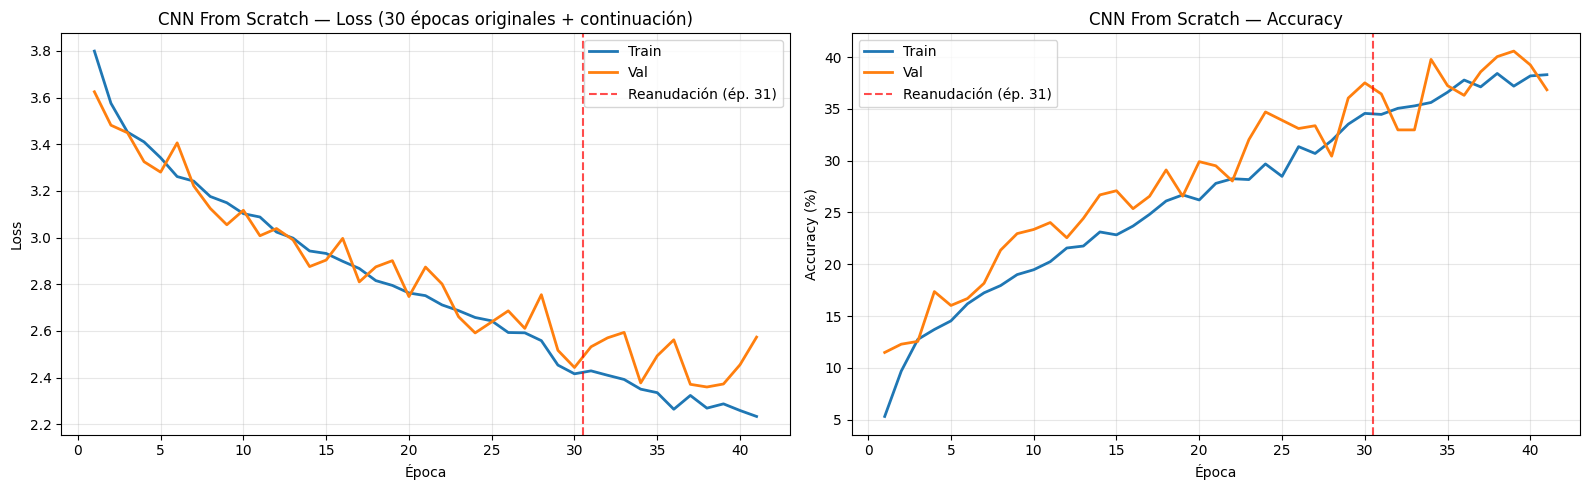

Curva combinada guardada. Total épocas graficadas: 41 (30+11)


In [6]:
# Curva combinada: 30 épocas originales + N épocas nuevas
full = {k: original_hist[k] + cont_history[k] for k in original_hist}
n_orig = len(original_hist['val_loss'])
n_cont = len(cont_history['val_loss'])
n_total = n_orig + n_cont

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
xs = list(range(1, n_total+1))

# Loss
axes[0].plot(xs, full['train_loss'], label='Train', linewidth=2, color='tab:blue')
axes[0].plot(xs, full['val_loss'], label='Val', linewidth=2, color='tab:orange')
axes[0].axvline(x=n_orig + 0.5, color='red', linestyle='--', alpha=0.7, label='Reanudación (ép. 31)')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].set_title('CNN From Scratch — Loss (30 épocas originales + continuación)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(xs, full['train_acc'], label='Train', linewidth=2, color='tab:blue')
axes[1].plot(xs, full['val_acc'], label='Val', linewidth=2, color='tab:orange')
axes[1].axvline(x=n_orig + 0.5, color='red', linestyle='--', alpha=0.7, label='Reanudación (ép. 31)')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('CNN From Scratch — Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../report/curvas_cnn_scratch_con_continuacion.png", dpi=100, bbox_inches='tight')
plt.show()
print(f"Curva combinada guardada. Total épocas graficadas: {n_total} ({n_orig}+{n_cont})")


In [7]:
# Evaluación en test con el MEJOR modelo (potencialmente actualizado)
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.to(device)

test_loss, test_acc = validate(model, test_loader, criterion, device)

print(f"\n{'='*50}")
print(f"RESULTADOS POST-CONTINUACIÓN — CNN FROM SCRATCH")
print(f"{'='*50}")
print(f"Test Accuracy previo (ép 30): 39.20%")
print(f"Test Accuracy actual:         {test_acc:.2f}%")
print(f"Δ:                            {test_acc - 39.20:+.2f} pts")
print(f"Umbral mínimo:                40.00%")
print(f"Estado: {'✅ APROBADO' if test_acc >= 40 else '❌ NO APROBADO'}")
print(f"{'='*50}")


C:\Users\HP\AppData\Local\Temp\ipykernel_22360\299500786.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=d

Val:   0%|          | 0/40 [00:00<?, ?it/s]

Val:   2%|▎         | 1/40 [00:06<04:03,  6.23s/it]

Val:  10%|█         | 4/40 [00:06<00:43,  1.22s/it]

Val:  18%|█▊        | 7/40 [00:06<00:19,  1.69it/s]

...

Val:  82%|████████▎ | 33/40 [00:08<00:00, 10.94it/s]

Val:  88%|████████▊ | 35/40 [00:08<00:00, 11.13it/s]

Val:  92%|█████████▎| 37/40 [00:09<00:00, 11.37it/s]

Val:  98%|█████████▊| 39/40 [00:09<00:00, 11.42it/s]


RESULTADOS POST-CONTINUACIÓN — CNN FROM SCRATCH
Test Accuracy previo (ép 30): 39.20%
Test Accuracy actual:         41.92%
Δ:                            +2.72 pts
Umbral mínimo:                40.00%
Estado: ✅ APROBADO


In [8]:
# Re-exportamos el modelo a TorchScript con el mejor estado actual
model.eval()
example_input = torch.randn(1, 3, 224, 224).to(device)
traced_model = torch.jit.trace(model, example_input)
TORCHSCRIPT_PATH = "../models/cnn_scratch_torchscript.pt"
traced_model.save(TORCHSCRIPT_PATH)
print(f"TorchScript re-exportado: {TORCHSCRIPT_PATH}")

loaded = torch.jit.load(TORCHSCRIPT_PATH)
loaded.eval()
print(f"Verificación OK - output shape: {loaded(example_input).shape}")


TorchScript re-exportado: ../models/cnn_scratch_torchscript.pt
Verificación OK - output shape: torch.Size([1, 50])
